# TimesFM 3 — factor forecast analysis

This notebook evaluates the zero-shot multivariate forecast produced by `forecast_factors.py`. It answers two separate questions:

1. **Did TimesFM improve historical forecasts?** Compare rolling out-of-sample errors with a zero-return baseline.
2. **What does the current forecast say?** Inspect the 20-step joint factor path and its marginal uncertainty.

The notebook reads saved CSV artifacts, so it is fast and does not reload the TimesFM checkpoint. A positive chart is not assumed to be meaningful: daily returns are noisy, and the aggregate result must survive a genuinely unseen holdout before downstream use.

## Prerequisite

Generate or refresh the artifacts from the repository root before running this notebook:

```powershell
python .\BinaryClassification\forecast_factors.py --model-dir .\BinaryClassification\model --output-dir .\BinaryClassification\timesfm_output --horizon 20 --context-length 512 --device cuda --batch-size 2 --backtest-windows 60
```

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

# Resolve paths whether the notebook starts from the repo root or BinaryClassification/.
cwd = Path.cwd().resolve()
REPO = cwd.parent if cwd.name == 'BinaryClassification' else cwd
BC = REPO / 'BinaryClassification'
OUTPUT = BC / 'timesfm_output'
DOCS = REPO / 'docs' / 'img'
DOCS.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True

INK, MUTED, GRAY = '#0b0b0b', '#52514e', '#c9c8c2'
BLUE, ORANGE, AQUA, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRAY, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'font.size': 10, 'axes.titlesize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

def finish(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(DOCS / filename, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()

In [3]:
required = ['factor_point.csv', 'factor_quantiles.csv', 'backtest.csv', 'metadata.json']
missing = [name for name in required if not (OUTPUT / name).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {', '.join(missing)} in {OUTPUT}. Run the prerequisite command first."
    )

point = pd.read_csv(OUTPUT / 'factor_point.csv', index_col=0)
point.index = point.index.astype(int)
quantiles = pd.read_csv(OUTPUT / 'factor_quantiles.csv', header=[0, 1], index_col=0)
quantiles.index = quantiles.index.astype(int)
quantiles.columns = pd.MultiIndex.from_tuples(
    [(factor, float(q)) for factor, q in quantiles.columns],
    names=['factor', 'quantile'],
)
metrics = pd.read_csv(OUTPUT / 'backtest.csv', index_col='factor')
metadata = json.loads((OUTPUT / 'metadata.json').read_text())
factor_metrics = metrics.drop(index='__overall__')
overall = metrics.loc['__overall__']
horizon = int(metadata['horizon'])
windows = int(round(factor_metrics['n'].iloc[0] / horizon))

summary = pd.DataFrame({
    'Value': [
        metadata['context_end'], horizon, windows, int(overall['n']),
        overall['mae_skill_vs_zero'], overall['directional_accuracy'],
    ]
}, index=[
    'Forecast origin', 'Forecast horizon', 'Backtest windows',
    'Factor-step predictions', 'MAE skill vs zero', 'Directional accuracy',
])
summary.loc['MAE skill vs zero', 'Value'] = f"{overall['mae_skill_vs_zero']:.2%}"
summary.loc['Directional accuracy', 'Value'] = f"{overall['directional_accuracy']:.1%}"
display(summary)

,Value
Forecast origin,2026-08-07 00:00:00+00:00
Forecast horizon,20
Backtest windows,60
Factor-step predictions,18000
MAE skill vs zero,0.03%
Directional accuracy,52.6%


## 1. Historical improvement versus predicting zero

MAE skill is $1 - \mathrm{MAE}_{TimesFM}/\mathrm{MAE}_{zero}$, so positive values are improvements and negative values are regressions. Directional accuracy is shown separately because a model can predict signs slightly better while failing to improve return magnitudes.

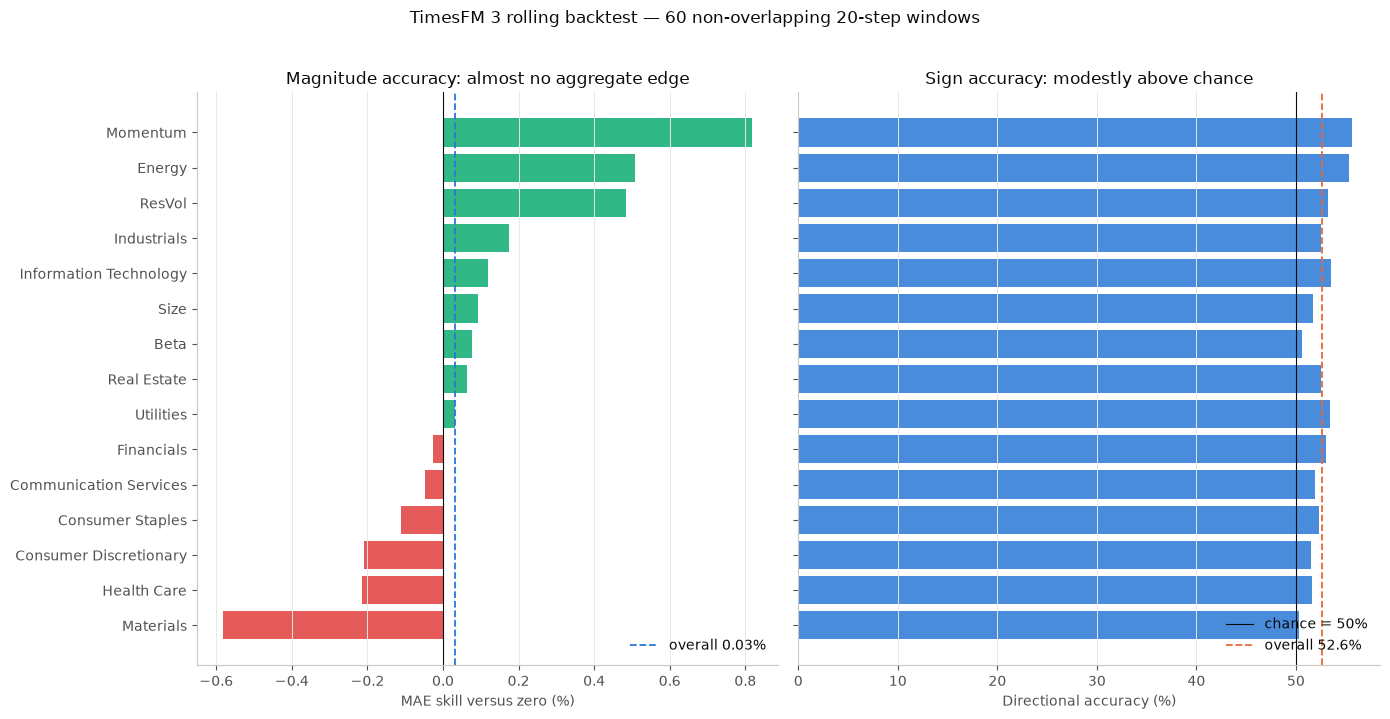

In [4]:
ordered = factor_metrics['mae_skill_vs_zero'].sort_values().index
skill_pct = factor_metrics.loc[ordered, 'mae_skill_vs_zero'] * 100
direction_pct = factor_metrics.loc[ordered, 'directional_accuracy'] * 100
colors = np.where(skill_pct >= 0, AQUA, RED)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
axes[0].barh(ordered, skill_pct, color=colors, alpha=0.9)
axes[0].axvline(0, color=INK, lw=0.8)
axes[0].axvline(overall['mae_skill_vs_zero'] * 100, color=BLUE, ls='--', lw=1.3,
                label=f"overall {overall['mae_skill_vs_zero']:.2%}")
axes[0].set_xlabel('MAE skill versus zero (%)')
axes[0].set_title('Magnitude accuracy: almost no aggregate edge')
axes[0].legend(frameon=False, loc='lower right')
axes[0].grid(axis='x', color='#e8e7e3', lw=0.7)

axes[1].barh(ordered, direction_pct, color=BLUE, alpha=0.85)
axes[1].axvline(50, color=INK, lw=0.8, label='chance = 50%')
axes[1].axvline(overall['directional_accuracy'] * 100, color=ORANGE, ls='--', lw=1.3,
                label=f"overall {overall['directional_accuracy']:.1%}")
axes[1].set_xlabel('Directional accuracy (%)')
axes[1].set_title('Sign accuracy: modestly above chance')
axes[1].grid(axis='x', color='#e8e7e3', lw=0.7)
axes[1].legend(frameon=False, loc='lower right')
fig.suptitle(f'TimesFM 3 rolling backtest — {windows} non-overlapping {horizon}-step windows', y=1.02)
finish(fig, 'timesfm_backtest_skill.png')

In [5]:
best_skill = factor_metrics['mae_skill_vs_zero'].idxmax()
best_direction = factor_metrics['directional_accuracy'].idxmax()
positive = int((factor_metrics['mae_skill_vs_zero'] > 0).sum())
print(f"{positive}/{len(factor_metrics)} factors beat zero on MAE.")
print(
    f"Best MAE skill: {best_skill} "
    f"({factor_metrics.loc[best_skill, 'mae_skill_vs_zero']:+.2%})."
)
print(
    f"Best directional accuracy: {best_direction} "
    f"({factor_metrics.loc[best_direction, 'directional_accuracy']:.1%})."
)
print(
    f"Overall MAE skill is {overall['mae_skill_vs_zero']:+.2%}: "
    "the larger backtest does not establish a broad magnitude-forecasting improvement."
)

9/15 factors beat zero on MAE.
Best MAE skill: Momentum (+0.82%).
Best directional accuracy: Momentum (55.7%).
Overall MAE skill is +0.03%: the larger backtest does not establish a broad magnitude-forecasting improvement.


## 2. Current joint factor forecast

The following paths compound the median point forecasts. They are conditional factor-return forecasts from the final context row, not expected stock returns and not a replacement for the covariance risk model.

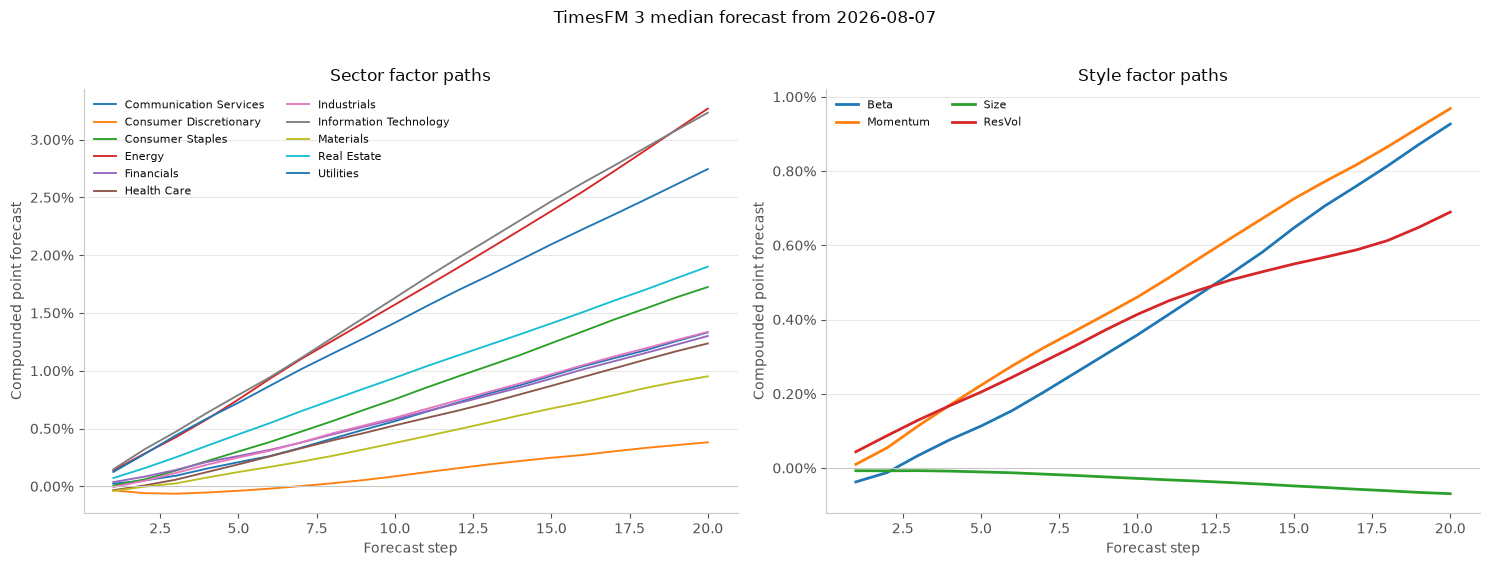

In [6]:
styles = [x for x in ['Beta', 'Momentum', 'Size', 'ResVol'] if x in point.columns]
sectors = [x for x in point.columns if x not in styles]
cumulative = (1 + point).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for factor in sectors:
    axes[0].plot(cumulative.index, cumulative[factor], lw=1.35, label=factor)
for factor in styles:
    axes[1].plot(cumulative.index, cumulative[factor], lw=2, label=factor)
for ax, title in zip(axes, ['Sector factor paths', 'Style factor paths']):
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set_xlabel('Forecast step')
    ax.set_ylabel('Compounded point forecast')
    ax.set_title(title)
    ax.grid(axis='y', color='#e8e7e3', lw=0.7)
    ax.legend(frameon=False, fontsize=8, ncol=2)
fig.suptitle(f"TimesFM 3 median forecast from {metadata['context_end'][:10]}", y=1.02)
finish(fig, 'timesfm_factor_paths.png')

## 3. Marginal forecast uncertainty

TimesFM supplies nine marginal quantiles per factor and step. The bands below are valid pointwise uncertainty summaries. They are **not joint simulated paths**, so quantile rows should not be compounded or summed into portfolio quantiles.

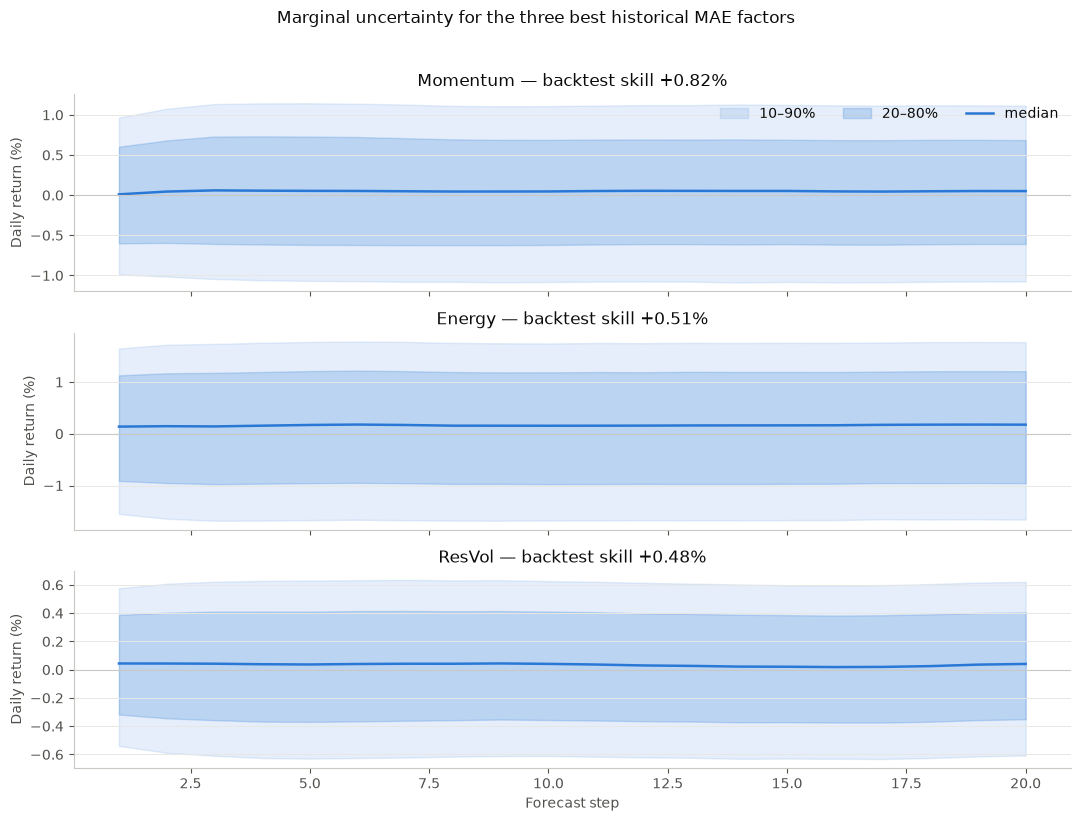

In [7]:
leaders = factor_metrics['mae_skill_vs_zero'].nlargest(3).index.tolist()
fig, axes = plt.subplots(len(leaders), 1, figsize=(11, 8), sharex=True)
steps = point.index.to_numpy()
for ax, factor in zip(np.atleast_1d(axes), leaders):
    q10 = quantiles[(factor, 0.1)].to_numpy() * 100
    q20 = quantiles[(factor, 0.2)].to_numpy() * 100
    q80 = quantiles[(factor, 0.8)].to_numpy() * 100
    q90 = quantiles[(factor, 0.9)].to_numpy() * 100
    median = point[factor].to_numpy() * 100
    ax.fill_between(steps, q10, q90, color=BLUE, alpha=0.12, label='10–90%')
    ax.fill_between(steps, q20, q80, color=BLUE, alpha=0.22, label='20–80%')
    ax.plot(steps, median, color=BLUE, lw=1.8, label='median')
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_ylabel('Daily return (%)')
    ax.set_title(
        f"{factor} — backtest skill {factor_metrics.loc[factor, 'mae_skill_vs_zero']:+.2%}"
    )
    ax.grid(axis='y', color='#e8e7e3', lw=0.7)
axes[0].legend(frameon=False, ncol=3, loc='upper right')
axes[-1].set_xlabel('Forecast step')
fig.suptitle('Marginal uncertainty for the three best historical MAE factors', y=1.02)
finish(fig, 'timesfm_quantile_fans.png')

## Interpretation

- The 60-window result is the decision-relevant one: aggregate MAE is effectively tied with predicting zero.
- Slightly better directional accuracy may be useful for ranking or sign decisions, but it needs a trading-cost-aware test and confidence intervals.
- The best-looking factors were selected after observing the same backtest. Treat them as hypotheses, not confirmed alpha.
- The strongest next test is to preserve the saved forecast and score it against OHLCV strictly after the recorded forecast origin. Do not tune the model on that holdout first.

TimesFM 3 checkpoint weights are currently restricted to non-commercial, non-production use.